In [76]:
import numpy as np
import pandas as pd

### Series 1D and Dataframe are 2D objectss
- But Why?
- And what exactly is index?

In [77]:
# can we have multiple index? Let's try
index_val = [('cse' , 2019) , ('cse' , 2020) , ('cse',2021) , ('cse',2022) , ('ece',2019), ('ece',2020) , ('ece',2021) , ('ece' , 2022)]
a = pd.Series([1,2,3,4,5,6,7,8] , index = index_val)
a

(cse, 2019)    1
(cse, 2020)    2
(cse, 2021)    3
(cse, 2022)    4
(ece, 2019)    5
(ece, 2020)    6
(ece, 2021)    7
(ece, 2022)    8
dtype: int64

In [78]:
# how to create multi-index objects
# 1. pd.MultiIndex.from_tuples()
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
multiindex.levels[1]

# 2. pd.MultiIndex.from_product() 
pd.MultiIndex.from_product([['cse' , 'ece'] , [2019,2020,2021,2022]])

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [79]:
# creating a series with multiindex object
s = pd.Series([1,2,3,4,5,6,7,8] , index = multiindex) 
s

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [80]:
s[('cse',2022)]
s['cse']

2019    1
2020    2
2021    3
2022    4
dtype: int64

In [81]:
# unstack
temp = s.unstack()

In [82]:
temp.stack()

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [83]:
# multi-index dataframe
branch_df1 = pd.DataFrame(
    [
        [1,2],
        [3,4],
        [5,6],
        [7,8],
        [9,10],
        [11,12],
        [13,14],
        [15,16],
    ],
    index = multiindex,
    columns = ['avg_package','students']
)
branch_df1

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [84]:
branch_df1.loc['cse']

,avg_package,students
2019,1,2
2020,3,4
2021,5,6
2022,7,8


In [85]:
branch_df1['avg_package']

cse  2019     1
     2020     3
     2021     5
     2022     7
ece  2019     9
     2020    11
     2021    13
     2022    15
Name: avg_package, dtype: int64

In [86]:
# Are Columns really different from index?
# Multi-Index df from columns persepective

branch_df2 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0]
    ],
    index = [2019,2020 , 2021, 2022],
    columns = pd.MultiIndex.from_product([['delhi' , 'mumbai'] , ['avg_package' , 'students']])
)
branch_df2

delhi               mumbai         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [87]:
# branch_df2['delhi']
branch_df2['delhi']['avg_package']

2019    1
2020    3
2021    5
2022    7
Name: avg_package, dtype: int64

In [88]:
branch_df2.iloc[2]

delhi   avg_package    5
        students       6
mumbai  avg_package    0
        students       0
Name: 2021, dtype: int64

In [89]:
# multi-index df in terms of both rows and columns
branch_df3 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)
branch_df3

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

### stacking and unstacking

In [90]:
branch_df1

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [91]:
branch_df1.unstack()
# the rows will become column and there will be multiindexig in columns

avg_package                students               
           2019 2020 2021 2022     2019 2020 2021 2022
cse           1    3    5    7        2    4    6    8
ece           9   11   13   15       10   12   14   16

In [92]:
branch_df1.unstack().unstack()
# brach cse,ece rows will become column

avg_package  2019  cse     1
                   ece     9
             2020  cse     3
                   ece    11
             2021  cse     5
                   ece    13
             2022  cse     7
                   ece    15
students     2019  cse     2
                   ece    10
             2020  cse     4
                   ece    12
             2021  cse     6
                   ece    14
             2022  cse     8
                   ece    16
dtype: int64

In [93]:
branch_df1.unstack().stack() # inner column will become rows

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\1548899124.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df1.unstack().stack() # inner column will become rows


avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [94]:
branch_df2.stack().stack() 

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\3935177274.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df2.stack().stack()


2019  avg_package  delhi     1
                   mumbai    0
      students     delhi     2
                   mumbai    0
2020  avg_package  delhi     3
                   mumbai    0
      students     delhi     4
                   mumbai    0
2021  avg_package  delhi     5
                   mumbai    0
      students     delhi     6
                   mumbai    0
2022  avg_package  delhi     7
                   mumbai    0
      students     delhi     8
                   mumbai    0
dtype: int64

In [95]:
branch_df3.stack().stack()

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\4023844418.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df3.stack().stack()


cse  2019  avg_package  delhi      1
                        mumbai     0
           students     delhi      2
                        mumbai     0
     2020  avg_package  delhi      3
                        mumbai     0
           students     delhi      4
                        mumbai     0
     2021  avg_package  delhi      5
                        mumbai     0
           students     delhi      6
                        mumbai     0
     2022  avg_package  delhi      7
                        mumbai     0
           students     delhi      8
                        mumbai     0
ece  2019  avg_package  delhi      9
                        mumbai     0
           students     delhi     10
                        mumbai     0
     2020  avg_package  delhi     11
                        mumbai     0
           students     delhi     12
                        mumbai     0
     2021  avg_package  delhi     13
                        mumbai     0
           students     delhi     14
 

### Working with mulitindex Dataframes

In [96]:
# head and tail
branch_df3.head()

# shape
branch_df3.shape

# info
branch_df3.info()

# duplicated -> isnull

branch_df3.duplicated()
branch_df3.isnull()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8 entries, ('cse', np.int64(2019)) to ('ece', np.int64(2022))
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   (delhi, avg_package)   8 non-null      int64
 1   (delhi, students)      8 non-null      int64
 2   (mumbai, avg_package)  8 non-null      int64
 3   (mumbai, students)     8 non-null      int64
dtypes: int64(4)
memory usage: 932.0+ bytes


delhi               mumbai         
         avg_package students avg_package students
cse 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False
ece 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False

In [97]:
# Extracting rows single
branch_df3.loc[('cse',2022)]

delhi   avg_package    7
        students       8
mumbai  avg_package    0
        students       0
Name: (cse, 2022), dtype: int64

In [98]:
# multiple
branch_df3.loc[ ('cse',2020) : ('ece',2021) : 2 ]

delhi               mumbai         
         avg_package students avg_package students
cse 2020           3        4           0        0
    2022           7        8           0        0
ece 2020          11       12           0        0

In [99]:
# using iloc
branch_df3.iloc[0:5:2]

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

In [100]:
# Extracting iloc

branch_df3.iloc[0:5:2]

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

In [101]:
# Extracting cols
branch_df3['delhi']['students']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: students, dtype: int64

In [102]:
branch_df3.iloc[: , 1:3]

delhi      mumbai
         students avg_package
cse 2019        2           0
    2020        4           0
    2021        6           0
    2022        8           0
ece 2019       10           0
    2020       12           0
    2021       14           0
    2022       16           0

In [103]:
# Extracting both

branch_df3.iloc[ [0,4] , [1,2]]

,,delhi,mumbai
,,students,avg_package
cse,2019,2,0
ece,2019,10,0


In [104]:
# sort index
# both -> descending -> diff order
# based on one level

branch_df3.sort_index(ascending = False)

delhi               mumbai         
         avg_package students avg_package students
ece 2022          15       16           0        0
    2021          13       14           0        0
    2020          11       12           0        0
    2019           9       10           0        0
cse 2022           7        8           0        0
    2021           5        6           0        0
    2020           3        4           0        0
    2019           1        2           0        0

In [105]:
branch_df3.sort_index(ascending = [False,True])

delhi               mumbai         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

In [106]:
branch_df3.sort_index(level = 0 , ascending=[False])

delhi               mumbai         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0


---

### 1. `branch_df3.sort_index(ascending=False)`

* **What it does:** Sorts **all levels** of the index in descending order.
* **Result:** It will first sort Level 0 ('ece' comes before 'cse' alphabetically) and then sort Level 1 (2022 down to 2019) within those groups.

### 2. `branch_df3.sort_index(ascending=[False, True])`

* **What it does:** Sorts different levels in **different orders** by passing a list of booleans corresponding to each index level.
* **Result:** * Level 0 (Branch) is sorted in descending order (`False`), so 'ece' appears before 'cse'.
* Level 1 (Year) is sorted in ascending order (`True`), so within 'ece' or 'cse', the years will go from 2019 up to 2022.



### 3. `branch_df3.sort_index(level=0, ascending=[False])`

* **What it does:** Explicitly targets and sorts **based on only one specific level** (Level 0) while keeping the original order of the other levels or sorting them as a secondary priority.
* **Result:** It tells pandas to focus its sorting on Level 0 (Branch) in descending order. (Note: In the iframe output shown below the cell, this effectively moves the 'ece' block above the 'cse' block).

In [107]:
# multi-index dataframe (col) -> transpose
branch_df3.transpose()

cse                 ece               
                   2019 2020 2021 2022 2019 2020 2021 2022
delhi  avg_package    1    3    5    7    9   11   13   15
       students       2    4    6    8   10   12   14   16
mumbai avg_package    0    0    0    0    0    0    0    0
       students       0    0    0    0    0    0    0    0

In [108]:
# swaplevel
branch_df3.swaplevel(axis=1)

avg_package students avg_package students
               delhi    delhi      mumbai   mumbai
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

This line of code is used to swap the hierarchical levels of a **MultiIndex** (a multi-level index) in a pandas DataFrame.

To understand exactly what `branch_df3.swaplevel(axis=1)` is doing from scratch, let's break it down into its core components.

---

### 1. The Setup: What is a MultiIndex?

Normally, a DataFrame has a single row index and a single column index. However, pandas allows you to have **hierarchical (multi-level) indexing**.

In your notebook, `branch_df3` has a MultiIndex on **both** its rows and its columns:

* **Rows (axis=0):** Level 0 is Branch (`cse`, `ece`) and Level 1 is Year (`2019`, `2020`, etc.).
* **Columns (axis=1):** Level 0 is City (`delhi`, `mumbai`) and Level 1 is Metric (`avg_package`, `students`).

Before running the code, your columns look structurally like this:

* **Level 0:** `delhi` | `mumbai`
* **Level 1:** `avg_package` | `students` | `avg_package` | `students`

---

### 2. Breaking Down the Code

#### `axis=1`

In pandas:

* `axis=0` refers to the **rows**.
* `axis=1` refers to the **columns**.

By passing `axis=1`, you are telling pandas: *"Leave the row indices alone. I want to change the structure of the column headers."*

#### `.swaplevel()`

By default, if you don't specify which levels to swap, this function switches the inner-most level with the outer-most level. Since your columns only have two levels (Level 0 and Level 1), it simply flips them.

---

### 3. The Before vs. After Effect

Here is how the column hierarchy shifts visually after running the cell:

**Before `swaplevel(axis=1)`:**
The DataFrame is grouped primarily by **City**, and then split by **Metric**:

```text
          delhi                 mumbai        <- Level 0 (City)
     avg_package  students  avg_package  students  <- Level 1 (Metric)

```

**After `swaplevel(axis=1)`:**
The levels are flipped. The DataFrame is now grouped primarily by **Metric**, and then split by **City**:

```text
     avg_package  students  avg_package  students  <- Old Level 1 (now Level 0)
          delhi     delhi        mumbai    mumbai  <- Old Level 0 (now Level 1)

```

### Summary

`branch_df3.swaplevel(axis=1)` changes the perspective of your data visualization. Instead of looking at *"Delhi's average package vs. Delhi's students"*, it restructures the columns so you can easily compare *"Average packages across Delhi and Mumbai"* side-by-side.

### Long Vs Wide Data

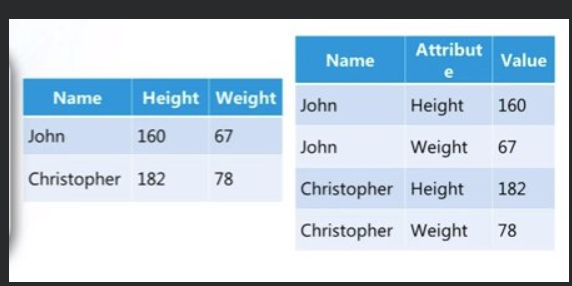

- **Wide format** is where we have a single row for every data point with multiple columns to hold the values of various attributes.

- **Long format** is where, for each data point we have as many rows as the number of attributes and each row contains the value of a particular attribute for a given data point.

In [109]:
# melt -> Does wide to long
pd.DataFrame({
    'cse' : [120]
})

,cse
0,120


In [110]:
pd.DataFrame({
    'cse' : [120]
}).melt()

,variable,value
0,cse,120


In [111]:
pd.DataFrame({
    'cse' : [120],
    'ece' : [100],
    'mech' : [50]
})

,cse,ece,mech
0,120,100,50


In [112]:
pd.DataFrame({
    'cse' : [120],
    'ece' : [100],
    'mech' : [50]
}).melt(var_name = 'branch' , value_name = 'number of students')

,branch,number of students
0,cse,120
1,ece,100
2,mech,50


In [113]:
pd.DataFrame(
    {
        'branch' : ['cse','ece','mech'],
        '2020' : [100,150,60],
        '2021' : [120,130,80],
        '2022' : [150,140,70]
    }
)

,branch,2020,2021,2022
0,cse,100,120,150
1,ece,150,130,140
2,mech,60,80,70


In [114]:
pd.DataFrame(
    {
        'branch' : ['cse','ece','mech'],
        '2020' : [100,150,60],
        '2021' : [120,130,80],
        '2022' : [150,140,70]
    }
).melt(id_vars=['branch'] , var_name = 'year' , value_name = 'students')

,branch,year,students
0,cse,2020,100
1,ece,2020,150
2,mech,2020,60
3,cse,2021,120
4,ece,2021,130
5,mech,2021,80
6,cse,2022,150
7,ece,2022,140
8,mech,2022,70


In [115]:
death = pd.read_csv('time_series_covid19_deaths_global.csv')
confirm = pd.read_csv('time_series_covid19_confirmed_global.csv')


In [116]:
death.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [117]:
death.shape

(289, 1081)

In [118]:
confirm.head(3)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229


In [119]:
# death = death.melt(id_vars=['Province/State' , 'Country/Region' , 'Lat' , 'Long' ],var_name = 'date' , value_name = 'num_of_death')
confirm = confirm.melt(id_vars=['Province/State' , 'Country/Region' , 'Lat' , 'Long' ],var_name = 'date' , value_name = 'num_of_death')

In [120]:
death

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,5708,5708,5708,5708,5708,5708,5708,5708,5708,5708
285,NaN,Winter Olympics 2022,39.904200,116.407400,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
286,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,2159,2159,2159,2159,2159,2159,2159,2159,2159,2159
287,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,4019,4019,4022,4022,4023,4023,4024,4024,4024,4024


In [121]:
confirm

,Province/State,Country/Region,Lat,Long,date,num_of_death
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,703228
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,535
311250,NaN,Yemen,15.552727,48.516388,1/2/23,11945
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,334661


In [122]:
confirm.merge(death , on = ['Province/State' , 'Country/Region' , 'Lat' , 'Long' ])[['Country/Region' , 'date' , 'num_of_death']]

,Country/Region,date,num_of_death
0,Afghanistan,1/22/20,0
1,Albania,1/22/20,0
2,Algeria,1/22/20,0
3,Andorra,1/22/20,0
4,Angola,1/22/20,0
...,...,...,...
311248,West Bank and Gaza,1/2/23,703228
311249,Winter Olympics 2022,1/2/23,535
311250,Yemen,1/2/23,11945
311251,Zambia,1/2/23,334661


In [123]:
confirm.merge(death , on = ['Province/State' , 'Country/Region' , 'Lat' , 'Long' ])[['Country/Region' , 'date' , 'num_of_death']]

,Country/Region,date,num_of_death
0,Afghanistan,1/22/20,0
1,Albania,1/22/20,0
2,Algeria,1/22/20,0
3,Andorra,1/22/20,0
4,Angola,1/22/20,0
...,...,...,...
311248,West Bank and Gaza,1/2/23,703228
311249,Winter Olympics 2022,1/2/23,535
311250,Yemen,1/2/23,11945
311251,Zambia,1/2/23,334661


### Pivot table
- The pivot table takes simple column-wise data as input, and groups the entries into a 2D table. That provides a multidimensional summarization of the data.

In [124]:
import seaborn as sns

In [125]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [126]:
df.groupby('sex')[['total_bill']].mean()

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\2388094044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [127]:
df[ (df['sex']=='Male') & (df['smoker'] == 'Yes') ][['total_bill']].mean()

total_bill    22.2845
dtype: float64

In [128]:
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\884363850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [129]:
df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill')

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\1070514850.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [132]:
# aggfunc
df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc='var')

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\1422483930.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc='var')


smoker,Yes,No
sex,,
Male,98.244673,76.152961
Female,84.451517,53.092422


In [136]:
df.pivot_table(index = 'sex' , columns = 'smoker', values=['total_bill' , 'tip' , 'size'])

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\3997300878.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = 'sex' , columns = 'smoker', values=['total_bill' , 'tip' , 'size'])


size                 tip           total_bill           
smoker       Yes        No       Yes        No        Yes         No
sex                                                                 
Male    2.500000  2.711340  3.051167  3.113402  22.284500  19.791237
Female  2.242424  2.592593  2.931515  2.773519  17.977879  18.105185

In [138]:
df.pivot_table(index = ['sex','smoker'] , columns = ['day','time'] , values = 'total_bill' , aggfunc = {'size' : 'mean' , 'tip' : 'max' , 'total_bill' : 'sum'})

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\3299338552.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = ['sex','smoker'] , columns = ['day','time'] , values = 'total_bill' , aggfunc = {'size' : 'mean' , 'tip' : 'max' , 'total_bill' : 'sum'})


KeyError: "Column(s) ['size', 'tip'] do not exist"

In [141]:
df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc = 'sum' , margins=True) # margins for total

C:\Users\hites\AppData\Local\Temp\ipykernel_12324\819509710.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc = 'sum' , margins=True) # margins for total


smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [143]:
# plotting graphs
df = pd.read_csv('expense_data.csv')
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [ ]:
df['Category'].value_counts()

Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [148]:
df['Date'] = pd.to_datetime(df['Date'])

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [156]:
df['Month'] = df['Date'].dt.month_name()
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


<Axes: xlabel='Month'>

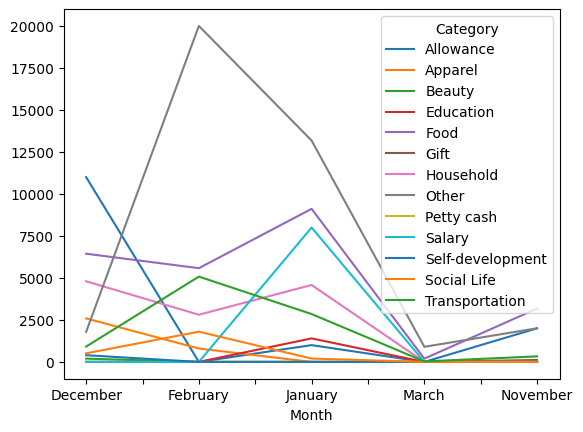

In [161]:
df.pivot_table(index = 'Month' , columns = 'Category' ,values='INR' , aggfunc = 'sum' , fill_value=0).plot()

<Axes: xlabel='Month'>

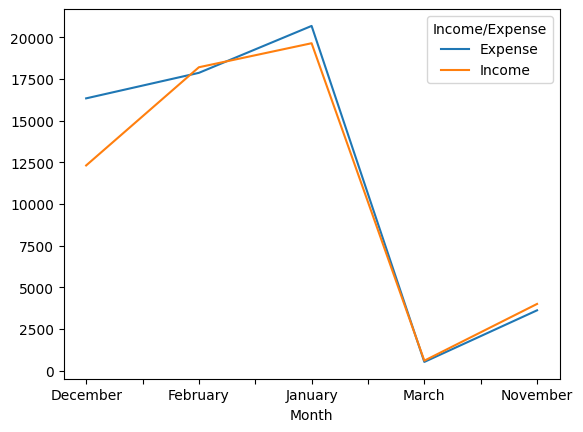

In [162]:
df.pivot_table(index = 'Month' , columns = 'Income/Expense' ,values='INR' , aggfunc = 'sum' , fill_value=0).plot()

<Axes: xlabel='Month'>

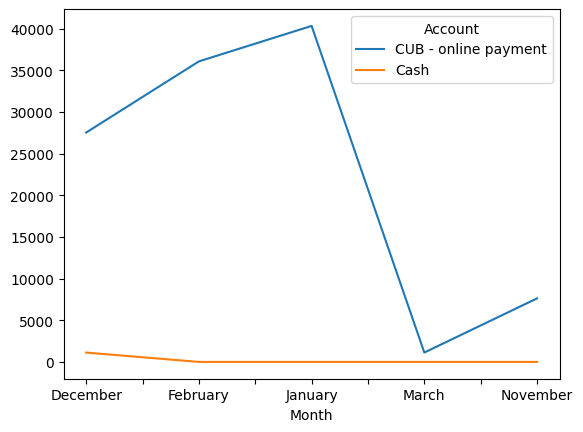

In [164]:
df.pivot_table(index = 'Month' , columns = 'Account' ,values='INR' , aggfunc = 'sum' , fill_value=0).plot()